In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/child-mind-institute-detect-sleep-states/train_series.parquet
/kaggle/input/child-mind-institute-detect-sleep-states/sample_submission.csv
/kaggle/input/child-mind-institute-detect-sleep-states/train_events.csv
/kaggle/input/child-mind-institute-detect-sleep-states/test_series.parquet


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import random

import dask #Library for parallel computing
import dask.array as da
import dask.dataframe as dd

In [3]:
%%time 
#Magic command - Time execution of a Python statement or expression. It prints the CPU and wall clock times.

import polars as pl
train_series = (pl.scan_parquet('/kaggle/input/child-mind-institute-detect-sleep-states/train_series.parquet')
                .with_columns(
                    (
                        (pl.col("timestamp").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%Z")),

                    )
                )
                .collect()
                .to_pandas()
               )

CPU times: user 1min 2s, sys: 22.4 s, total: 1min 24s
Wall time: 53.9 s


### Why polars?
Pandas is the go-to option for data practitioners using Python, but, it comes with several important limitations when it comes to dealing with large datasets - pandas is threaded, meaning that it cannot leverage parallel computing techniques that are now common in data science.The core mission of polars is to offer a lightning-fast dataframe library that addresses all the problems of pandas.

### Memory reduction

In [4]:
from pandas.api.types import is_datetime64_ns_dtype
import gc

import warnings
warnings.filterwarnings("ignore")

def reduce_mem_usage(df):
    
    """ 
    Iterate through all numeric columns of a dataframe and modify the data type
    to reduce memory usage.        
    """
    
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage of dataframe is {start_mem:.2f} MB')
    
    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object and not is_datetime64_ns_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float32)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        

    df['series_id'] = df['series_id'].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization is: {end_mem:.2f} MB')
    decrease = 100 * (start_mem - end_mem) / start_mem
    print(f'Decreased by {decrease:.2f}%')
    
    return df

In [5]:
train_series = reduce_mem_usage(train_series)

Memory usage of dataframe is 3416.54 MB
Memory usage after optimization is: 2684.43 MB
Decreased by 21.43%


In [6]:
train_series.head()

,series_id,step,timestamp,anglez,enmo
0,038441c925bb,0.0,2018-08-14 15:30:00,2.6367,0.0217
1,038441c925bb,1.0,2018-08-14 15:30:05,2.6368,0.0215
2,038441c925bb,2.0,2018-08-14 15:30:10,2.6370,0.0216
3,038441c925bb,3.0,2018-08-14 15:30:15,2.6368,0.0213
4,038441c925bb,4.0,2018-08-14 15:30:20,2.6368,0.0215


In [7]:
#Read train_events csv file
train_events = (pl.scan_csv('/kaggle/input/child-mind-institute-detect-sleep-states/train_events.csv')
                .with_columns(
                    (
                        (pl.col("timestamp").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%Z")),
                        (pl.col("timestamp").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%Z").dt.year().alias("year")),
                        (pl.col("timestamp").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%Z").dt.month().alias("month")),
                        (pl.col("timestamp").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%Z").dt.day().alias("day")),
                        (pl.col("timestamp").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%Z").dt.hour().alias("hour")),
                    )
                )
                .collect()
                .to_pandas()
               )
train_events.head()

,series_id,night,event,step,timestamp,year,month,day,hour
0,038441c925bb,1,onset,4992.0,2018-08-14 22:26:00,2018.0,8.0,14.0,22.0
1,038441c925bb,1,wakeup,10932.0,2018-08-15 06:41:00,2018.0,8.0,15.0,6.0
2,038441c925bb,2,onset,20244.0,2018-08-15 19:37:00,2018.0,8.0,15.0,19.0
3,038441c925bb,2,wakeup,27492.0,2018-08-16 05:41:00,2018.0,8.0,16.0,5.0
4,038441c925bb,3,onset,39996.0,2018-08-16 23:03:00,2018.0,8.0,16.0,23.0


In [8]:
#Convert timestamp to year, month, day, and hour
#train_events['date'] =  pd.to_datetime(train_events['timestamp'], errors = 'coerce', utc = True) ## pandas recognizes your format

#train_events['year'] = train_events['date'].dt.year
#train_events['month'] = train_events['date'].dt.month
#train_events['day'] = train_events['date'].dt.day
#train_events['hour'] = train_events['date'].dt.hour
#train_events.head()

 # ***Preprocess the data***

In [9]:
#Sort the train_series dataset by the timestamp
train_series = train_series.sort_values('timestamp').reset_index(drop=True)
train_series.head()

,series_id,step,timestamp,anglez,enmo
0,fe90110788d2,0.0,2017-08-04 17:30:00,-27.707001,0.0298
1,fe90110788d2,1.0,2017-08-04 17:30:05,-33.867500,0.0488
2,fe90110788d2,2.0,2017-08-04 17:30:10,-15.475000,0.1077
3,fe90110788d2,3.0,2017-08-04 17:30:15,-73.656197,0.0530
4,fe90110788d2,4.0,2017-08-04 17:30:20,-53.152901,0.0601


In [10]:
#Sort the train_events dataset by the timestamp
train_events = train_events.sort_values('timestamp').reset_index(drop=True)
train_events.head()

,series_id,night,event,step,timestamp,year,month,day,hour
0,fe90110788d2,2,onset,21048.0,2017-08-05 22:44:00,2017.0,8.0,5.0,22.0
1,fe90110788d2,2,wakeup,27852.0,2017-08-06 08:11:00,2017.0,8.0,6.0,8.0
2,fe90110788d2,3,onset,38064.0,2017-08-06 22:22:00,2017.0,8.0,6.0,22.0
3,fe90110788d2,3,wakeup,42384.0,2017-08-07 04:22:00,2017.0,8.0,7.0,4.0
4,fe90110788d2,4,onset,54060.0,2017-08-07 20:35:00,2017.0,8.0,7.0,20.0


In [11]:
#print("Train Series Shape:", train_series.shape)
#print("Train Events Shape:", train_events.shape)

In [12]:
train_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14508 entries, 0 to 14507
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   series_id  14508 non-null  object        
 1   night      14508 non-null  int64         
 2   event      14508 non-null  object        
 3   step       9585 non-null   float64       
 4   timestamp  9585 non-null   datetime64[ns]
 5   year       9585 non-null   float64       
 6   month      9585 non-null   float64       
 7   day        9585 non-null   float64       
 8   hour       9585 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 1020.2+ KB


### Sleep hours distribution

* Extract the hour and day components from the difference between the rows of the timestamp columns
* Make the difference between the rows of the timestamp columns
* Create a pandas dataframe named train_sleep

Since there are missing values in the train_events dataframe that can make the difference big, eliminate rows with a "day" value greater than 0 (it is good practice)  - of course assuming they have never slept for more than 24 hours.
After the difference, the events are equal to -1 and +1, corresponding to hours of sleep and hours of wakefulness, respectively.
For our purpose, only the events = -1 will be kept.

In [13]:
### Difference between the rows of the timestamp column
#Get Time Difference between Timestamps
train_events_hours = train_events.timestamp.diff().dt.components['hours']   # Extract the hour component from the difference
train_events_days  = train_events.timestamp.diff().dt.components['days']    # Extract the day component from the difference
train_events_event = train_events.event.map({'onset':1, 'wakeup':0}).diff() # Encode the events and make the difference

In [14]:
### Create the pandas dataframe
train_sleep = pd.DataFrame([train_events.month, train_events.day, train_events_days, train_events_hours, train_events_event], 
                           index=['month', 'day', 'days_sleep', 'hours_sleep', 'event']).T.dropna()
train_sleep = train_sleep[(train_sleep.days_sleep == 0) & (train_sleep.event == -1)].reset_index(drop=True)

In [15]:
train_sleep.head()

,month,day,days_sleep,hours_sleep,event
0,8.0,6.0,0.0,9.0,-1.0
1,8.0,7.0,0.0,6.0,-1.0
2,8.0,8.0,0.0,12.0,-1.0
3,8.0,9.0,0.0,6.0,-1.0
4,8.0,10.0,0.0,5.0,-1.0


In [16]:
train_sleep.describe()

,month,day,days_sleep,hours_sleep,event
count,735.000000,735.000000,735.0,735.000000,735.0
mean,6.512925,15.834014,0.0,3.994558,-1.0
std,3.519821,8.865307,0.0,2.200439,0.0
min,1.000000,1.000000,0.0,0.000000,-1.0
25%,3.000000,8.000000,0.0,2.000000,-1.0
50%,6.000000,16.000000,0.0,4.000000,-1.0
75%,10.000000,24.000000,0.0,6.000000,-1.0
max,12.000000,31.000000,0.0,12.000000,-1.0


### Interpolation of the timestamp
Time series interpolation is the process of estimating missing data points in a time series by using the surrounding data points. This is useful here since we are working with data that is missing values. Interpolation can help to smooth out the data and make it easier to analyze and visualize.I

In [17]:
train_events.head(20)

,series_id,night,event,step,timestamp,year,month,day,hour
0,fe90110788d2,2,onset,21048.0,2017-08-05 22:44:00,2017.0,8.0,5.0,22.0
1,fe90110788d2,2,wakeup,27852.0,2017-08-06 08:11:00,2017.0,8.0,6.0,8.0
2,fe90110788d2,3,onset,38064.0,2017-08-06 22:22:00,2017.0,8.0,6.0,22.0
3,fe90110788d2,3,wakeup,42384.0,2017-08-07 04:22:00,2017.0,8.0,7.0,4.0
4,fe90110788d2,4,onset,54060.0,2017-08-07 20:35:00,2017.0,8.0,7.0,20.0
5,fe90110788d2,4,wakeup,62760.0,2017-08-08 08:40:00,2017.0,8.0,8.0,8.0
6,fe90110788d2,5,onset,72804.0,2017-08-08 22:37:00,2017.0,8.0,8.0,22.0
7,ece2561f07e9,1,onset,8976.0,2017-08-09 00:43:00,2017.0,8.0,9.0,0.0
8,fe90110788d2,5,wakeup,78876.0,2017-08-09 07:03:00,2017.0,8.0,9.0,7.0
9,ece2561f07e9,1,wakeup,15972.0,2017-08-09 10:26:00,2017.0,8.0,9.0,10.0


In [18]:
train_events['timestamp'] = train_events.timestamp.interpolate()
train_events.head(20)

,series_id,night,event,step,timestamp,year,month,day,hour
0,fe90110788d2,2,onset,21048.0,2017-08-05 22:44:00,2017.0,8.0,5.0,22.0
1,fe90110788d2,2,wakeup,27852.0,2017-08-06 08:11:00,2017.0,8.0,6.0,8.0
2,fe90110788d2,3,onset,38064.0,2017-08-06 22:22:00,2017.0,8.0,6.0,22.0
3,fe90110788d2,3,wakeup,42384.0,2017-08-07 04:22:00,2017.0,8.0,7.0,4.0
4,fe90110788d2,4,onset,54060.0,2017-08-07 20:35:00,2017.0,8.0,7.0,20.0
5,fe90110788d2,4,wakeup,62760.0,2017-08-08 08:40:00,2017.0,8.0,8.0,8.0
6,fe90110788d2,5,onset,72804.0,2017-08-08 22:37:00,2017.0,8.0,8.0,22.0
7,ece2561f07e9,1,onset,8976.0,2017-08-09 00:43:00,2017.0,8.0,9.0,0.0
8,fe90110788d2,5,wakeup,78876.0,2017-08-09 07:03:00,2017.0,8.0,9.0,7.0
9,ece2561f07e9,1,wakeup,15972.0,2017-08-09 10:26:00,2017.0,8.0,9.0,10.0


### Merge the train_event and train_series datasets

Merge the train_series dataset AND the 'timestamp' and'event' features/columns in the train_events dataset.

In [19]:
train_events_to_merge = train_events[['timestamp', 'event']]
train_events_to_merge.head()

,timestamp,event
0,2017-08-05 22:44:00,onset
1,2017-08-06 08:11:00,wakeup
2,2017-08-06 22:22:00,onset
3,2017-08-07 04:22:00,wakeup
4,2017-08-07 20:35:00,onset


In [20]:
#Check the number of NaN values in the two columns of the newly created train_events_to_merge pandas DataFrame.
train_events_to_merge.isna().sum()

timestamp    0
event        0
dtype: int64

In [21]:
train_events_to_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14508 entries, 0 to 14507
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  14508 non-null  datetime64[ns]
 1   event      14508 non-null  object        
dtypes: datetime64[ns](1), object(1)
memory usage: 226.8+ KB


In [22]:
train_series_merged = train_series.merge(train_events_to_merge, how='left', on='timestamp')
train_series_merged.head()

,series_id,step,timestamp,anglez,enmo,event
0,fe90110788d2,0.0,2017-08-04 17:30:00,-27.707001,0.0298,NaN
1,fe90110788d2,1.0,2017-08-04 17:30:05,-33.867500,0.0488,NaN
2,fe90110788d2,2.0,2017-08-04 17:30:10,-15.475000,0.1077,NaN
3,fe90110788d2,3.0,2017-08-04 17:30:15,-73.656197,0.0530,NaN
4,fe90110788d2,4.0,2017-08-04 17:30:20,-53.152901,0.0601,NaN


### Fill the missing values in the event column

Use the 'ffill' method to replace NaN values with the value from the previous row.

In [23]:
train_series_merged['event'] = train_series_merged.event.fillna(method='ffill')

In this manner, the initial rows with missing values remain unchanged since there are no preceding values to replace them. When inspecting the train_events dataset, we observe that the initial event is 'onset', signifying the start of sleep. Consequently, the event immediately preceding 'onset' is 'wakeup.' To address this, we will proceed to populate the remaining rows with missing values with 'wakeup.'

In [24]:
train_series_merged['event'] = train_series_merged.event.fillna('wakeup')
train_series_merged.head()

,series_id,step,timestamp,anglez,enmo,event
0,fe90110788d2,0.0,2017-08-04 17:30:00,-27.707001,0.0298,wakeup
1,fe90110788d2,1.0,2017-08-04 17:30:05,-33.867500,0.0488,wakeup
2,fe90110788d2,2.0,2017-08-04 17:30:10,-15.475000,0.1077,wakeup
3,fe90110788d2,3.0,2017-08-04 17:30:15,-73.656197,0.0530,wakeup
4,fe90110788d2,4.0,2017-08-04 17:30:20,-53.152901,0.0601,wakeup


In [25]:
#Check for missing values in the event column
train_series_merged.event.isna().sum()

0

## Data Exploration

In [26]:
#Check train_events dataset
train_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14508 entries, 0 to 14507
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   series_id  14508 non-null  object        
 1   night      14508 non-null  int64         
 2   event      14508 non-null  object        
 3   step       9585 non-null   float64       
 4   timestamp  14508 non-null  datetime64[ns]
 5   year       9585 non-null   float64       
 6   month      9585 non-null   float64       
 7   day        9585 non-null   float64       
 8   hour       9585 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(2)
memory usage: 1020.2+ KB


In [27]:
#Explore the train_events dataset
train_events.describe()

,night,step,timestamp,year,month,day,hour
count,14508.000000,9585.000000,14508,9585.000000,9585.000000,9585.000000,9585.000000
mean,15.120072,214352.123944,2018-11-03 10:38:26.277915904,2017.997809,6.496609,15.987585,12.127804
min,1.000000,936.000000,2017-08-05 22:44:00,2017.000000,1.000000,1.000000,0.000000
25%,7.000000,95436.000000,2018-03-31 05:47:15,2018.000000,3.000000,8.000000,6.000000
50%,14.000000,200604.000000,2018-12-19 22:44:30,2018.000000,6.000000,16.000000,8.000000
75%,21.000000,317520.000000,2019-07-05 05:33:00,2018.000000,10.000000,24.000000,21.000000
max,84.000000,739392.000000,2019-07-05 05:33:00,2019.000000,12.000000,31.000000,23.000000
std,10.286758,141268.408192,NaN,0.660645,3.667130,8.818433,7.944063


In [28]:
#Get unique values of Series object
print('Number of unique identifiers for each series of accelerometer data:', len(train_events.series_id.unique()))

Number of unique identifiers for each series of accelerometer data: 277


### Hours distribution

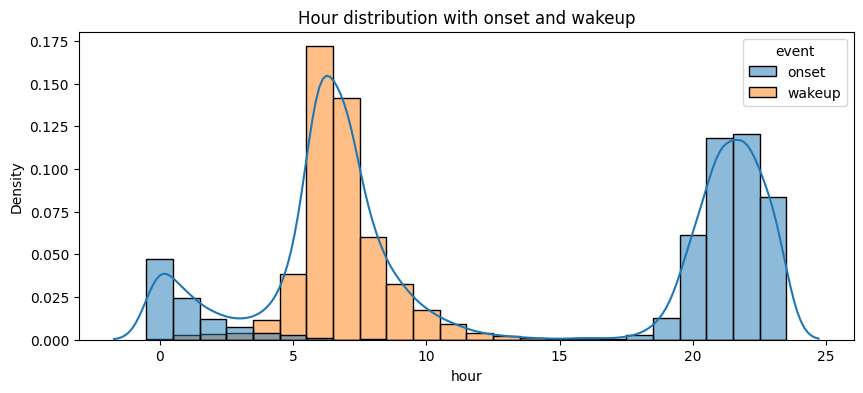

In [29]:
plt.figure(figsize=(10,4))
plt.title('Hour distribution with onset and wakeup')
sns.histplot(x=train_events.dropna().hour, hue=train_events.dropna().event, stat='density', bins=24, binrange=(-0.5, 23.5))
sns.kdeplot(train_events.dropna().hour, bw_adjust=0.45);

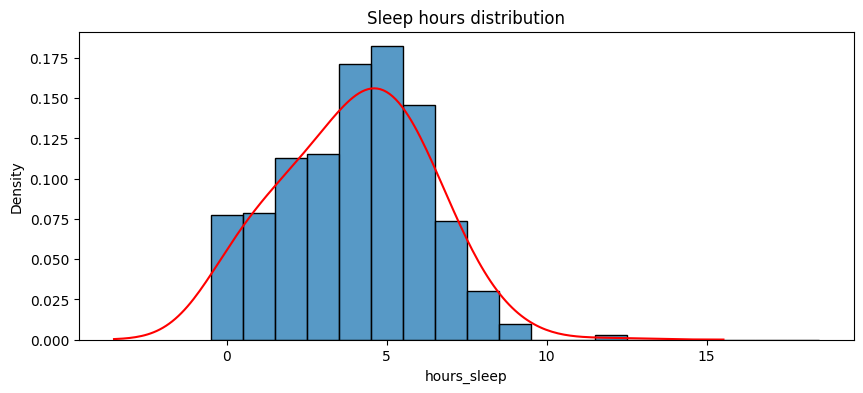

In [30]:
#Sleep hours distribution
plt.figure(figsize=(10,4))
plt.title('Sleep hours distribution')
sns.histplot(x=train_sleep.hours_sleep, stat='density', bins=19, binrange=(-0.5, 18.5))
sns.kdeplot(train_sleep.hours_sleep, bw_adjust=2, color='red');

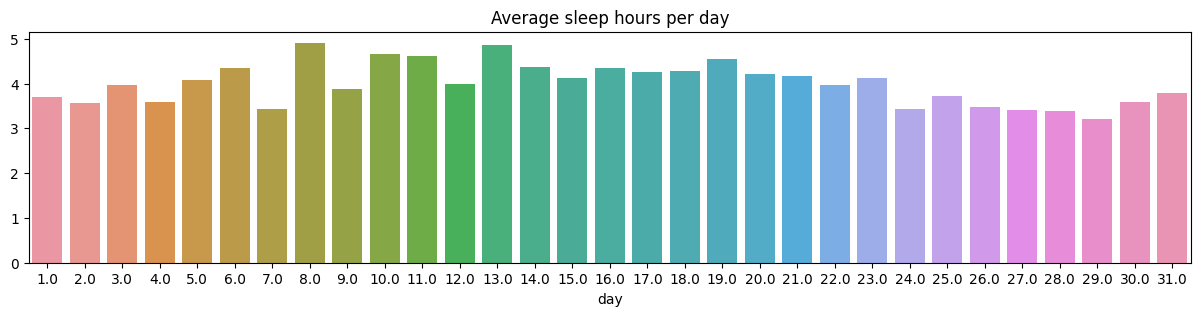

In [31]:
#Average sleep hours per day
plt.figure(figsize=(15,3))
plt.title('Average sleep hours per day')
sns.barplot(x=train_sleep.groupby('day').hours_sleep.mean().index, y=train_sleep.groupby('day').hours_sleep.mean().values);

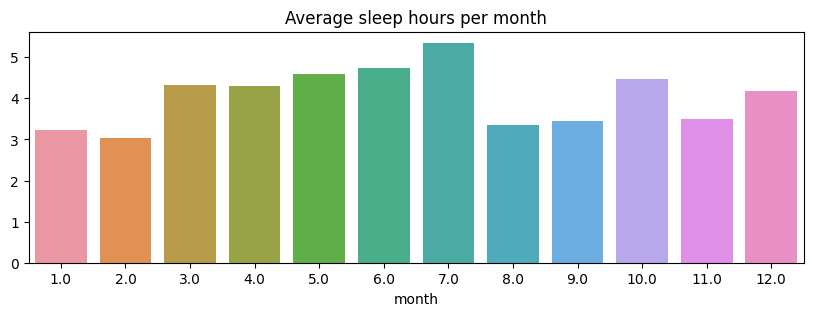

In [32]:
#Average sleep hours per month
plt.figure(figsize=(10,3))
plt.title('Average sleep hours per month')
sns.barplot(x=train_sleep.groupby('month').hours_sleep.mean().index, y=train_sleep.groupby('month').hours_sleep.mean().values);

The average number of sleep hour is about 12 hours. It could have been hypothesized that in the summer months and on weekends, the hours of sleep were greater.Is this hypothesis visible in the data? Not at all! Thus it is rejected.

## Explore the train_series_merged dataset

In [33]:
train_series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127946340 entries, 0 to 127946339
Data columns (total 5 columns):
 #   Column     Dtype         
---  ------     -----         
 0   series_id  category      
 1   step       float32       
 2   timestamp  datetime64[ns]
 3   anglez     float32       
 4   enmo       float32       
dtypes: category(1), datetime64[ns](1), float32(3)
memory usage: 2.6 GB


In [34]:
#Check for any missing values
train_series.isna().sum()

series_id    0
step         0
timestamp    0
anglez       0
enmo         0
dtype: int64

In [35]:
#Get unique values of Series object
print(f'In the dataset there are {len(train_series.series_id.unique())} accelerometer series')

In the dataset there are 277 accelerometer series


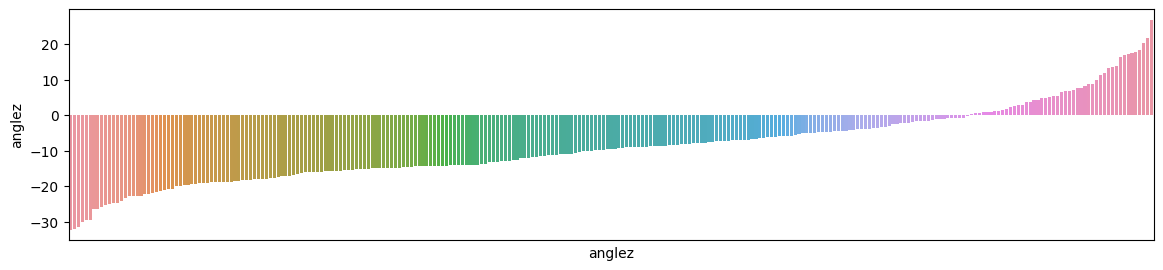

In [36]:
plt.figure(figsize=(14,3))
sns.barplot(x=train_series.groupby('series_id').anglez.mean(),
            y=train_series.groupby('series_id').anglez.mean())
g = plt.xticks(ticks=[])

### Take five random series_id and explore them

In [37]:
series_id_selected = random.choices(train_series_merged.series_id.unique(), k = 5)
series_id_selected

['77ca4db83644',
 '3665c86afaf5',
 'cfeb11428dd7',
 '29c75c018220',
 '18a0ca03431d']

In [38]:
# Extract a subset of the dataset with the selected series id
train_series_subset = train_series_merged[train_series_merged.series_id.isin(series_id_selected)].reset_index(drop=True)
train_series_subset.shape

(2840091, 6)

In [39]:
#Convert from datetime to timestamp
train_series_subset['timestamp_new'] = train_series_subset.timestamp.astype(int).div(10**9)
train_series_subset.head()

,series_id,step,timestamp,anglez,enmo,event,timestamp_new
0,3665c86afaf5,0.0,2017-08-21 17:00:00,86.799797,0.0001,wakeup,1.503335e+09
1,3665c86afaf5,1.0,2017-08-21 17:00:05,86.670799,0.0001,wakeup,1.503335e+09
2,3665c86afaf5,2.0,2017-08-21 17:00:10,86.662598,0.0001,wakeup,1.503335e+09
3,3665c86afaf5,3.0,2017-08-21 17:00:15,86.670799,0.0001,wakeup,1.503335e+09
4,3665c86afaf5,4.0,2017-08-21 17:00:20,86.670799,0.0001,wakeup,1.503335e+09


CPU times: user 1.25 s, sys: 99.5 ms, total: 1.35 s
Wall time: 1.28 s


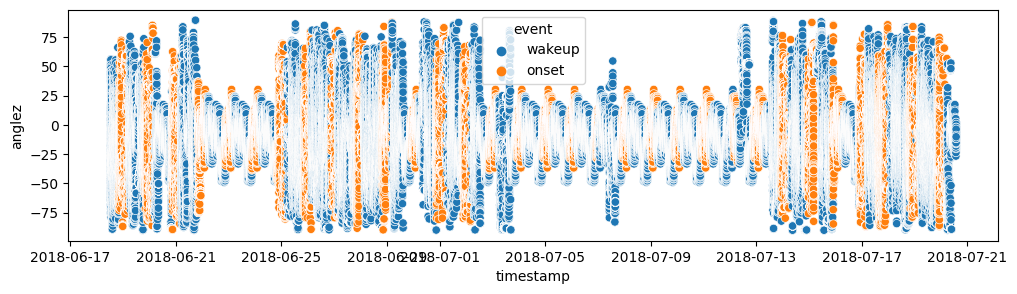

In [40]:
%%time
plt.figure(figsize=(12,3))
sns.scatterplot(data=train_series_subset[train_series_subset.series_id == series_id_selected[0]],
             x='timestamp', y='anglez', hue='event');

CPU times: user 1.34 s, sys: 66.2 ms, total: 1.4 s
Wall time: 1.35 s


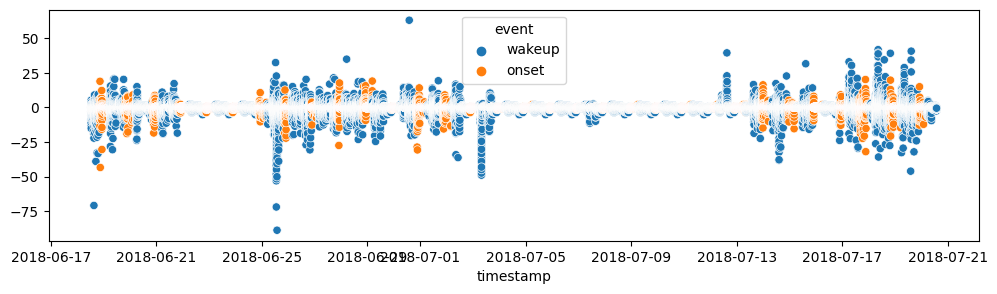

In [41]:
%%time
plt.figure(figsize=(12,3))
sns.scatterplot(x=train_series_subset[train_series_subset.series_id == series_id_selected[0]].timestamp,
                y=train_series_subset[train_series_subset.series_id == series_id_selected[0]].anglez*train_series_subset[train_series_subset.series_id == series_id_selected[0]].enmo,
                hue=train_series_subset[train_series_subset.series_id == series_id_selected[0]].event);

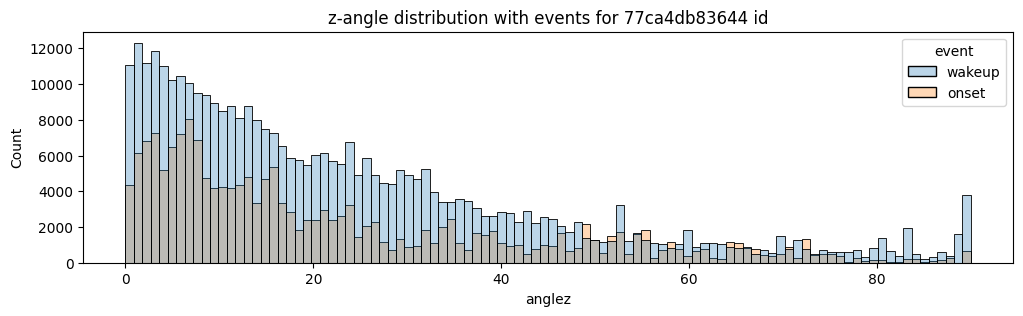

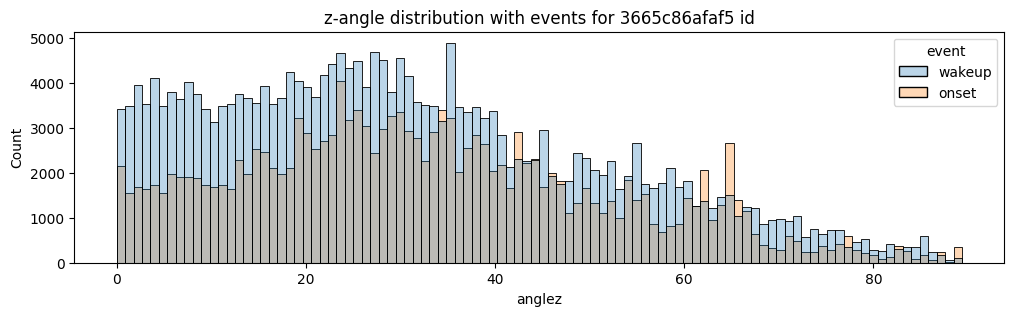

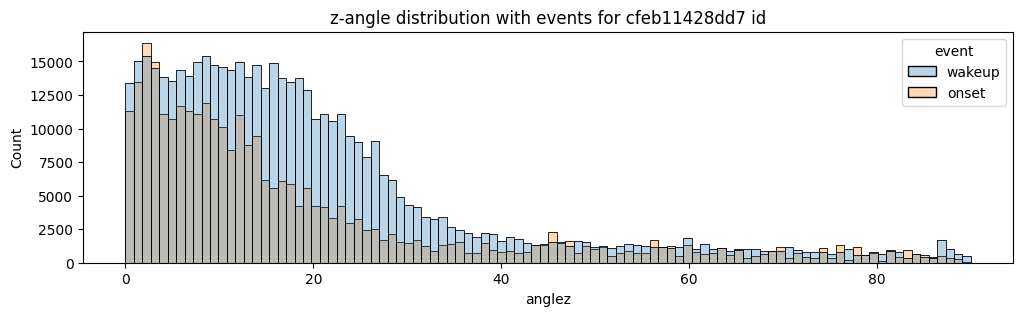

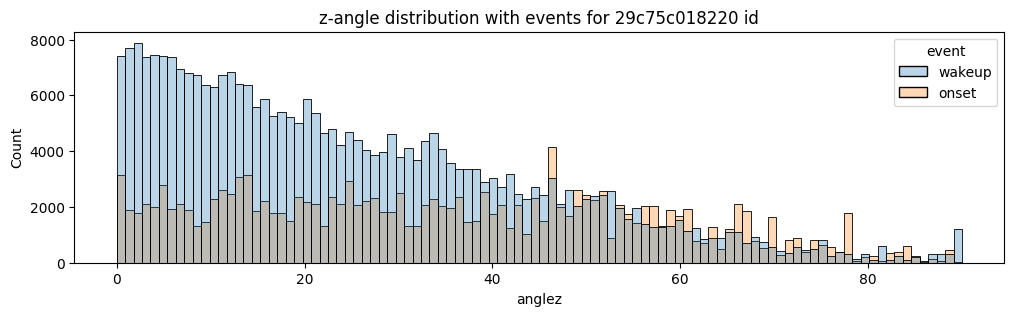

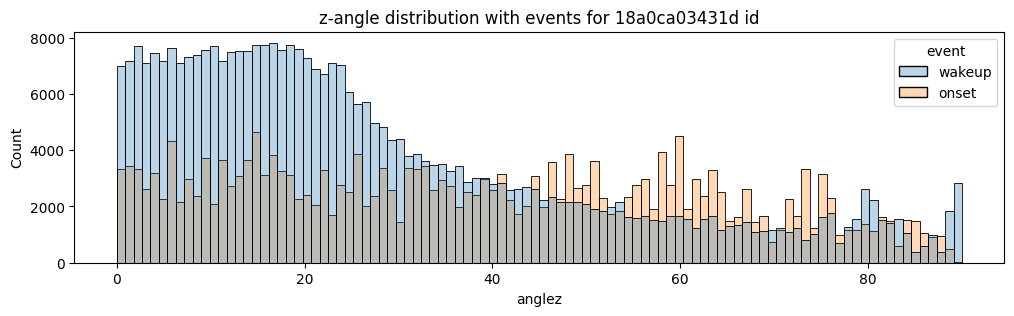

CPU times: user 7.49 s, sys: 831 ms, total: 8.32 s
Wall time: 7.1 s


In [42]:
%%time
for ids in series_id_selected:
    plt.figure(figsize=(12,3))
    plt.title(f'z-angle distribution with events for {ids} id')
    sns.histplot(data=train_series_subset[train_series_subset.series_id == ids],
                 x=train_series_subset[train_series_subset.series_id == ids].anglez.abs(), hue='event', fill=True, bins=100, alpha=0.3)
    plt.show()

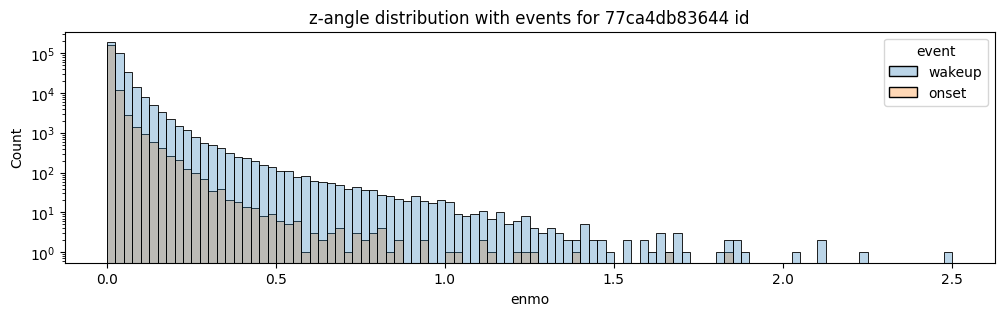

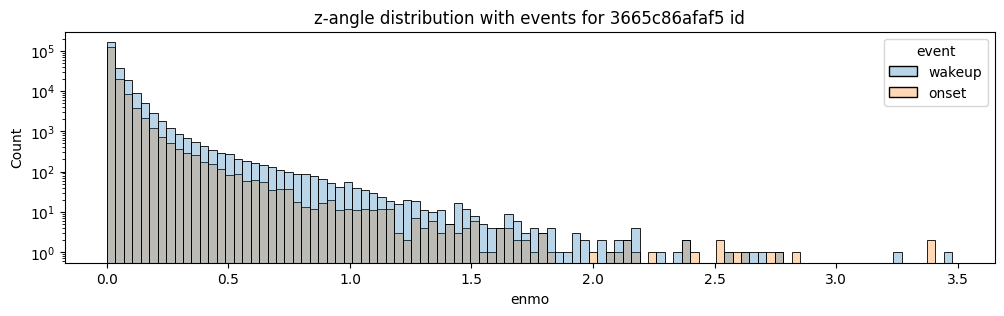

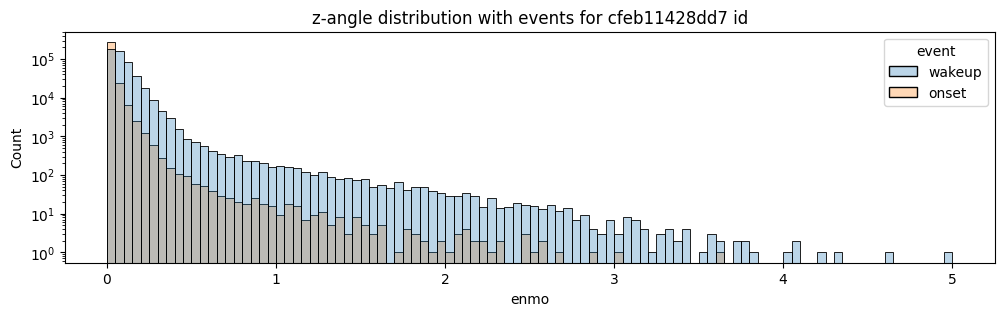

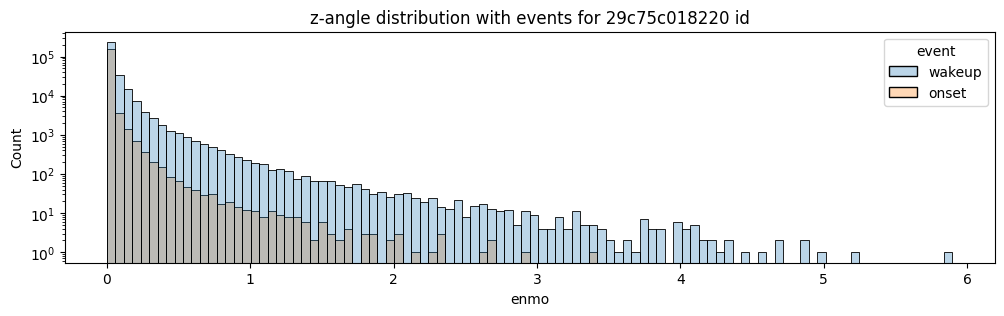

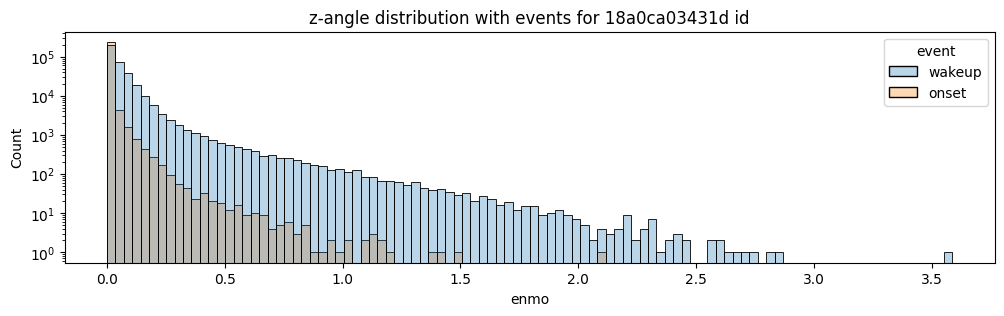

CPU times: user 9.79 s, sys: 754 ms, total: 10.5 s
Wall time: 9.34 s


In [43]:
%%time
for ids in series_id_selected:
    plt.figure(figsize=(12,3))
    plt.title(f'z-angle distribution with events for {ids} id')
    sns.histplot(data=train_series_subset[train_series_subset.series_id == ids],
                 x='enmo', hue='event', fill=True, bins=100, alpha=0.3)
    plt.yscale('log')
    plt.show()

### Observations from the z-angle distribution:

* the wakeup probability decrases as the absolute value of the angle increases.
* the onset probability is almost constant for all the angle values, except for a few peaks

Also, from the ENMO distribution both the event count decreases as the enmo encreases

CPU times: user 1.09 s, sys: 53 ms, total: 1.14 s
Wall time: 1.06 s


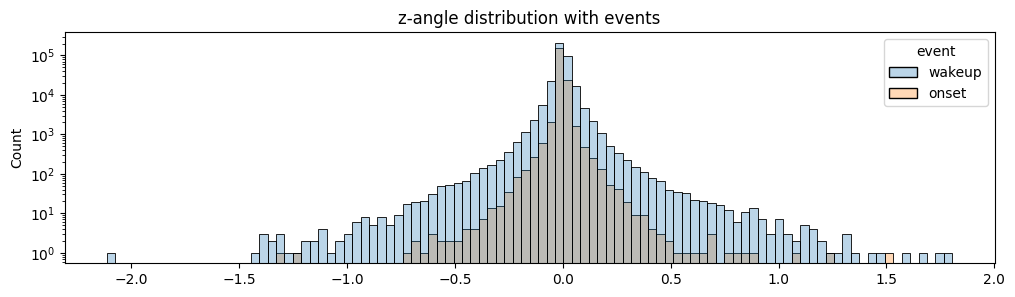

In [44]:
%%time
plt.figure(figsize=(12,3))
plt.title('z-angle distribution with events')
sns.histplot(data=train_series_subset[train_series_subset.series_id == series_id_selected[0]],
             x=np.sin(train_series_subset[train_series_subset.series_id == series_id_selected[0]].anglez)*\
             (train_series_subset[train_series_subset.series_id == series_id_selected[0]].enmo), 
             hue='event', fill=True, bins=100, alpha=0.3)
plt.yscale('log')

### Preprocess the test dataset

In [45]:
%%time
test_series = (pl.scan_parquet('/kaggle/input/child-mind-institute-detect-sleep-states/test_series.parquet')
                .with_columns(
                    (
                        (pl.col("timestamp").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%Z")),

                    )
                )
                .collect()
                .to_pandas()
               )

CPU times: user 3.34 ms, sys: 2.31 ms, total: 5.65 ms
Wall time: 8.48 ms


In [46]:
test_series = reduce_mem_usage(test_series)

Memory usage of dataframe is 0.01 MB
Memory usage after optimization is: 0.01 MB
Decreased by 23.71%


In [47]:
test_series.head()

,series_id,step,timestamp,anglez,enmo
0,038441c925bb,0.0,2018-08-14 15:30:00,2.6367,0.0217
1,038441c925bb,1.0,2018-08-14 15:30:05,2.6368,0.0215
2,038441c925bb,2.0,2018-08-14 15:30:10,2.6370,0.0216
3,038441c925bb,3.0,2018-08-14 15:30:15,2.6368,0.0213
4,038441c925bb,4.0,2018-08-14 15:30:20,2.6368,0.0215


### Save the datasets

In [48]:
train_series_merged.to_parquet('/kaggle/working/train_series_preprocessed.parquet')
test_series.to_parquet('/kaggle/working/test_series_preprocessed.parquet')

Note that Kaggle has a memory limit of 8GB per kernel. So since the dataset is large, to avoid long times, preprocessing of the dataset was done in its own notebook , and then uploaded in second notebook and start the training part there. See Detect Sleep States: Decision Tree Model for the trained model.
